In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, 
                           random_state=41,hypercube=False, class_sep=30)

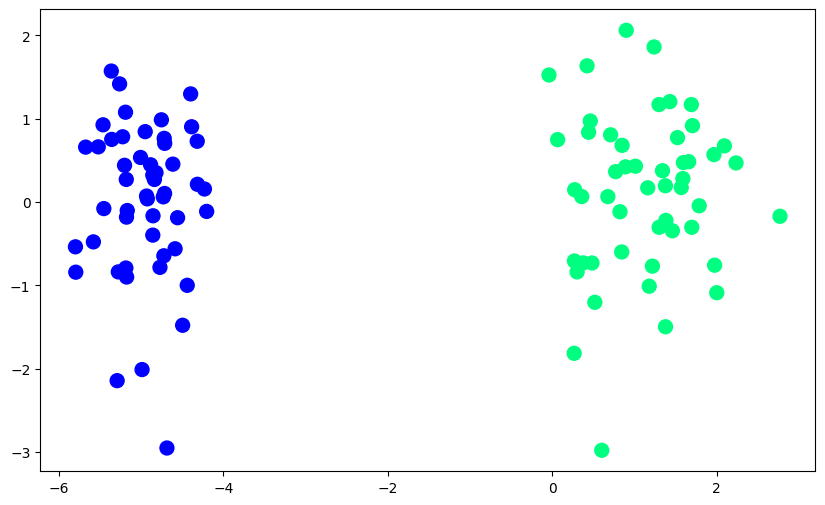

In [2]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.show()

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
lor = LogisticRegression(penalty=None, solver='sag', max_iter=1000)
lor.fit(X, y)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
print(lor.coef_)
print(lor.intercept_)

[[4.22192237 0.19822523]]
[5.90079218]


In [6]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [7]:
x_input = np.linspace(-3,3,100)
y_input = m1 * x_input + b1

In [8]:
def GD(X, y):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(20000):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])

    return weights[1:], weights[0]

In [9]:
def sigmoid(z):
    return 1 /(1 + np.exp(-z))

In [10]:
coef_, intercept_ = GD(X, y)

In [11]:
print(coef_)
print(intercept_)

[3.97755173 0.16951542]
6.3053913448695385


In [12]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [13]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m * x_input1 + b

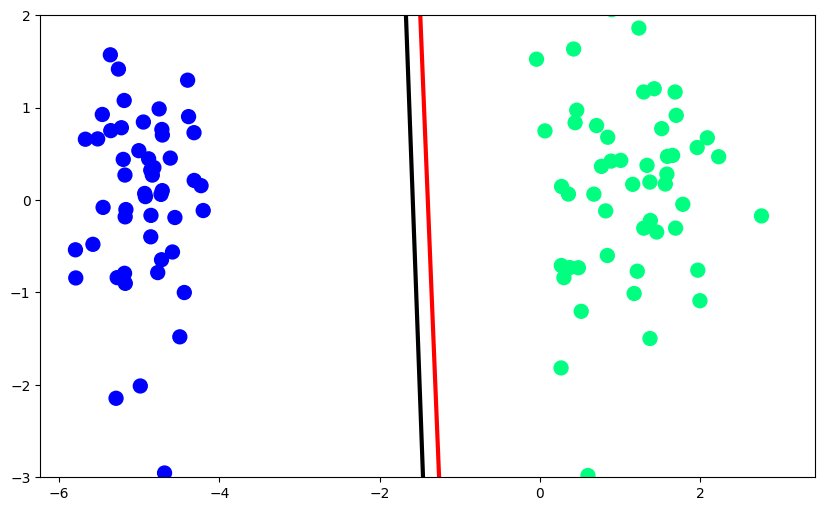

In [14]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
plt.show()